# Problem 3
***

In [1]:
from arch import arch_model
from arch.__future__ import reindexing
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import math

In [2]:
# Importing all the variables to make it easier

# Define the ticker. For each of the tickers I add the corresponding names

tickers = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'BP': 'BP plc',
    'JNJ': 'Johnson & Johnson',
    'NVS': 'Novartis AG',
    'KO': 'The Coca Cola Company',
    'UL': 'Unilever Plc',
    'JPM': 'JP Morgan Chase & Co',
    'BCS': 'Barclays Plc',
    'SONY': 'Sony',
    '^GSPC': 'S&P Index 500'
}

# Defining the start and end date for the data.
start_date = '2013-01-01'
end_date = '2023-05-31'

# Download historical data. Using a for loop that goes through all tickers, with start as start_date and end as end_date given. The ['Adj Close'] only gives the 
#Adjusted close column with the correct index. 
data = {}
for ticker, name in tickers.items():
    data[name] = yf.download(ticker, start=start_date, end=end_date, ignore_tz=True)['Adj Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


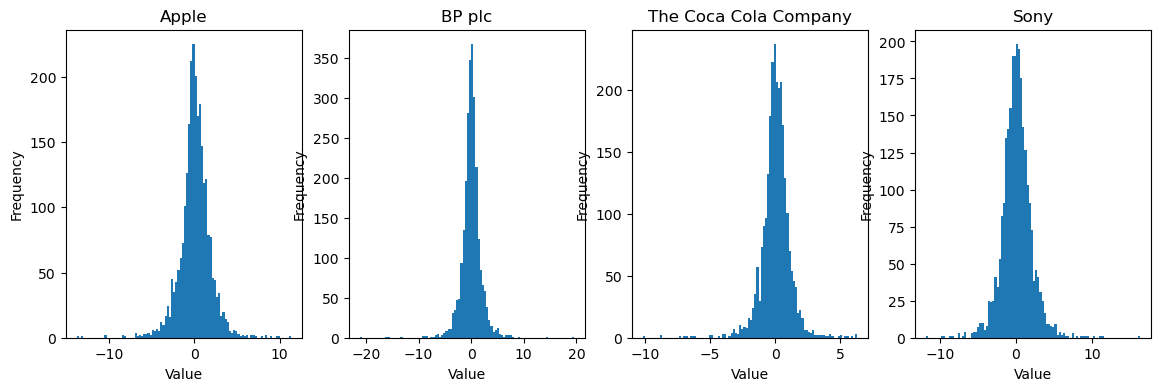

In [3]:
stocks = ["Apple", "BP plc", "The Coca Cola Company", "Sony"]
log_ret = {}

fig, axs = plt.subplots(1, 4, figsize=(14, 4))


# Multiplying with 100 becuase of scaling for the arch model
for i, ticker in enumerate(stocks):
    log_ret[ticker] = 100*np.log(data[ticker] / data[ticker].shift(1))
    axs[i].hist(log_ret[ticker], bins=100)
    axs[i].set_title(ticker)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')

In [4]:
garch_model = {}
gm_result = {}

for ticker in stocks:
    garch_model[ticker] = arch_model(log_ret[ticker].dropna(), p = 1, q = 1, mean = 'constant', vol = 'GARCH')
    gm_result[ticker] = garch_model[ticker].fit(disp='off')

In [5]:
# Using the lecture notes to calculate the expected conditional variance for the next 10 days, to arrive at a prediction of what the stock price
# will be in 10 days. 
gm_forecast = {}
for ticker in stocks:
    gm_forecast[ticker] = gm_result[ticker].forecast(horizon = 10)
    display(gm_forecast[ticker].variance[-1:])

,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10
Date,,,,,,,,,,
2023-05-30,1.70918,1.784471,1.85617,1.924448,1.989467,2.051385,2.110348,2.166498,2.219969,2.270889


,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10
Date,,,,,,,,,,
2023-05-30,2.951051,2.963171,2.97523,2.987229,2.999168,3.011047,3.022868,3.034629,3.046332,3.057976


,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10
Date,,,,,,,,,,
2023-05-30,0.758584,0.76944,0.780026,0.790348,0.800413,0.810228,0.819798,0.829131,0.83823,0.847103


,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10
Date,,,,,,,,,,
2023-05-30,3.176935,3.233709,3.285782,3.333542,3.377348,3.417527,3.454378,3.488178,3.519179,3.547613


In [6]:
# To forecast future returns, one can use the conditional variance with a Monte Carlo simulation of a normal distribution if you assume the earlier data is 
# normally distributed. Looking at the histograms the log returns look kind of normally distributed, and therefore I assume that it is that for the last 252 values. 
# I will also only be estimating the future return after 10 days. Doing a 1000 monte carlo iterations to find a prediction of the stock prices in 10 days.
# Creating a vector with the mean of each of the assets. The standard deviation is the square root of the predicted variance. 
vector = []
for i,name in enumerate(stocks):
    vector.append(log_ret[name].tail(252).mean())


# Creating the variances in a matrix, where row number equals stock number, and column number is variance in what day in the prediction. 
variances = np.zeros((4,10))
for i,name in enumerate(stocks):
    mid = pd.DataFrame(gm_forecast[name].variance[-1:])
    variances[i] = mid

In [7]:
# Creating the cumulative sum for each of the 100000 runs and storing in prediction.
prediction = np.zeros((4,100000))

for n in list(range(100000)):
    for i, ticker in enumerate(stocks):
        vector_2 = [vector[i]]*10
        random_return = np.random.normal(vector_2, np.sqrt(variances[i,:]))
        random_return = random_return.cumsum()
        prediction[i,n] = random_return[9]

In [8]:
# Taking the average of the prediction and finding the predicted log return of each of the assets (Numerated order)
predicted_10_days = {}
for i, ticker in enumerate(stocks):
    predicted_10_days[ticker] = round(prediction[i,:].mean(),4)


print(predicted_10_days)

{'Apple': 0.8667, 'BP plc': 0.4592, 'The Coca Cola Company': -0.1761, 'Sony': 0.2227}


In [9]:
std_10_days = {}
for i, ticker in enumerate(stocks):
    std_10_days[ticker] = round(prediction[i,:].std(),4)

print(std_10_days)

{'Apple': 4.4765, 'BP plc': 5.476, 'The Coca Cola Company': 2.8411, 'Sony': 5.8175}


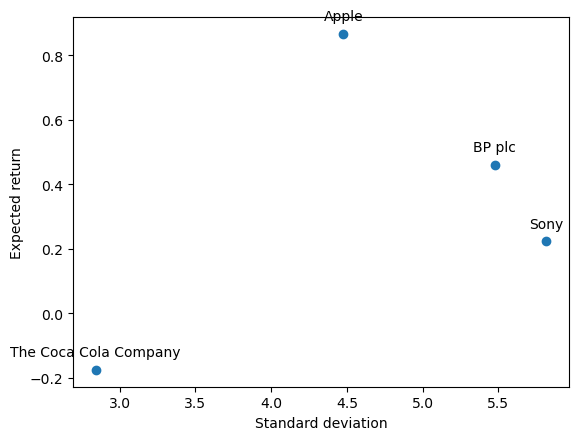

In [10]:
# Calculating the risk/return and plotting it we get:
list1 = list(std_10_days.values())
list2 = list(predicted_10_days.values())

result = [y/x for x, y in zip(list1, list2)]
plt.scatter(list1,list2)
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
for i, name in enumerate(stocks):
    plt.annotate(name, (list1[i], list2[i]), textcoords="offset points", xytext=(0,10), ha='center')

##### Based on the GARCH analysis I would not arrive at a conclusion. This is because the way to predict the stock after 10 days is mostly coming from the average of the last 252 days (In my solution). This makes the simulation go towards these means when the simulation numbers go up. However, it can be useful to see what the expected volatility for an asset is. 
##### From the plot we can see that Apple is the "best" asset of the four. This is only relient on the calculated standard deviation and expected return of the last 252 days. The coca cola company has mean of negative return on the last year and is therefore not good, based on the provided information in the garch analysis. The asset that is expected to have the most volatility is Sony, and closely following is BP plc. Apple is a bit further down. Also, the standard deviation is not per day, but in total for the predicted log return at day 10. 